<h1 style="color: black;"> Bonjour et bienvenue au Jour 6 ! 💪</h1>
<h2>Aujourd'hui c'est le Mini-projet ETL — tu vas construire ton premier pipeline de données complet de bout en bout, comme un vrai data scientist en entreprise !</h1>

<h1 style="color: red;"  >🎯 Objectif du jour </h1

<h2 style="color:blue">Construire un pipeline ETL (Extract, Transform, Load) complet qui collecte des données depuis plusieurs sources, les nettoie, les transforme et produit un rapport final.</h2>

<h3> Extract : collecter les données.<h3>

<h4><b>Setup et imports :</b></h4>

In [3]:
import pandas as pd
import numpy as np
import json
import requests
import logging
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Créer les dossiers EN PREMIER avant tout !
os.makedirs("jour06/output", exist_ok=True)

# Configuration du logging APRÈS création des dossiers
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("jour06/etl_pipeline.log", encoding="utf-8"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

logger.info("[START] Démarrage du pipeline ETL")
print("Setup terminé !")

2026-04-03 07:14:05,094 - INFO - [START] Démarrage du pipeline ETL


Setup terminé !


<p style = "color:red">  💡 os.makedirs(..., exist_ok=True) crée le dossier s'il n'existe pas — sans exist_ok=True ça planterait si le dossier existe déjà. Très utile dans les pipelines !</P>

<h4><b>Extract 1 : Générer les données de ventes :<b></h4>

In [4]:
def extract_ventes():
    logger.info("[EXTRACT] Génération des données de ventes...")
    
    np.random.seed(42)
    n = 200  # 200 transactions
    
    df_ventes = pd.DataFrame({
        "transaction_id": range(1, n+1),
        "client_id": np.random.randint(1, 51, n),
        "produit": np.random.choice(["Laptop", "Téléphone", "Tablette", 
                                     "Accessoire", "Imprimante"], n),
        "categorie": np.random.choice(["Electronique", "Accessoire", 
                                       "Informatique"], n),
        "montant": np.random.randint(5000, 800000, n),
        "quantite": np.random.randint(1, 10, n),
        "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", 
                                   "Garoua", "Bamenda"], n),
        "date": pd.date_range(start="2025-01-01", periods=n, freq="D"),
        "satisfaction": np.random.randint(1, 6, n)
    })
    
    # Introduire quelques valeurs manquantes intentionnellement
    df_ventes.loc[np.random.choice(n, 10), "satisfaction"] = np.nan
    df_ventes.loc[np.random.choice(n, 5), "montant"] = np.nan
    
    # Sauvegarder
    df_ventes.to_csv("jour06/ventes_raw.csv", index=False)
    logger.info(f"[OK] Ventes extraites — {df_ventes.shape[0]} lignes")
    
    return df_ventes

df_ventes_raw = extract_ventes()
print(df_ventes_raw.head())
print(f"\nValeurs manquantes :\n{df_ventes_raw.isnull().sum()}")

2026-04-03 07:21:40,451 - INFO - [EXTRACT] Génération des données de ventes...
2026-04-03 07:21:40,710 - INFO - [OK] Ventes extraites — 200 lignes


   transaction_id  client_id     produit     categorie   montant  quantite  \
0               1         39    Tablette    Accessoire  182804.0         4   
1               2         29      Laptop  Informatique  710703.0         9   
2               3         15  Accessoire  Informatique   44081.0         6   
3               4         43      Laptop  Informatique  723216.0         1   
4               5          8      Laptop  Electronique  360249.0         8   

    ville       date  satisfaction  
0  Douala 2025-01-01           2.0  
1  Douala 2025-01-02           2.0  
2  Douala 2025-01-03           NaN  
3  Douala 2025-01-04           4.0  
4  Douala 2025-01-05           4.0  

Valeurs manquantes :
transaction_id     0
client_id          0
produit            0
categorie          0
montant            5
quantite           0
ville              0
date               0
satisfaction      10
dtype: int64


<p style="color: red">💡 On introduit volontairement des valeurs manquantes pour simuler des données réelles imparfaites — c'est toujours le cas en entreprise !</p>

<h4><b> Extract 2 : Données clients depuis JSON et taux de change depuis API :</b></h4>

In [5]:
def extract_clients():
    logger.info("[EXTRACT] Génération des données clients...")
    
    np.random.seed(123)
    clients = pd.DataFrame({
        "client_id": range(1, 51),
        "nom": [f"Client_{i}" for i in range(1, 51)],
        "age": np.random.randint(18, 65, 50),
        "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam",
                                   "Garoua", "Bamenda"], 50),
        "segment": np.random.choice(["Premium", "Standard", "VIP"], 50)
    })
    
    # Sauvegarder en JSON
    clients_json = clients.to_dict(orient="records")
    with open("jour06/clients.json", "w", encoding="utf-8") as f:
        json.dump(clients_json, f, ensure_ascii=False, indent=4)
    
    logger.info(f"[OK] Clients extraits — {len(clients)} clients")
    return clients

def extract_taux_change():
    logger.info("[EXTRACT] Récupération des taux de change...")
    
    try:
        url = "https://api.exchangerate-api.com/v4/latest/XAF"
        response = requests.get(url, timeout=10)
        data = response.json()
        
        taux = {
            "EUR": data["rates"]["EUR"],
            "USD": data["rates"]["USD"],
            "date": data["date"]
        }
        logger.info(f"[OK] Taux récupérés — 1 XAF = {taux['EUR']:.6f} EUR")
        return taux
        
    except Exception as e:
        logger.warning(f"[WARNING] API indisponible : {e} — taux par défaut utilisés")
        return {"EUR": 0.00152, "USD": 0.00166, "date": "défaut"}

# Extraire
df_clients_raw = extract_clients()
taux = extract_taux_change()

print("=== CLIENTS ===")
print(df_clients_raw.head())
print(f"\n=== TAUX DE CHANGE ===")
print(f"1 XAF = {taux['EUR']} EUR")
print(f"1 XAF = {taux['USD']} USD")
print(f"Date : {taux['date']}")

2026-04-03 07:43:08,192 - INFO - [EXTRACT] Génération des données clients...
2026-04-03 07:43:08,213 - INFO - [OK] Clients extraits — 50 clients
2026-04-03 07:43:08,216 - INFO - [EXTRACT] Récupération des taux de change...
2026-04-03 07:43:09,601 - INFO - [OK] Taux récupérés — 1 XAF = 0.001520 EUR


=== CLIENTS ===
   client_id       nom  age      ville   segment
0          1  Client_1   63  Bafoussam  Standard
1          2  Client_2   20    Bamenda  Standard
2          3  Client_3   46     Garoua   Premium
3          4  Client_4   52     Garoua  Standard
4          5  Client_5   56    Bamenda   Premium

=== TAUX DE CHANGE ===
1 XAF = 0.00152 EUR
1 XAF = 0.00176 USD
Date : 2026-04-03


<P style="color: red"><b> 💡 timeout=10 dans requests.get() — si l'API ne répond pas en 10 secondes, on passe au plan B (taux par défaut). C'est indispensable en production pour éviter qu'un pipeline reste bloqué indéfiniment !</b></P>

<h3 style="color:blue"><b>  Transform : nettoyer et enrichir !</b></h3>

<h4><b> Transform : nettoyage des données :</b></h4>

In [6]:
def transform_nettoyage(df_ventes, df_clients):
    logger.info("[TRANSFORM] Début du nettoyage...")
    
    df = df_ventes.copy()
    
    # 1. Valeurs manquantes
    nb_manquants_avant = df.isnull().sum().sum()
    df["satisfaction"] = df["satisfaction"].fillna(df["satisfaction"].median())
    df["montant"] = df["montant"].fillna(df["montant"].median())
    nb_manquants_apres = df.isnull().sum().sum()
    logger.info(f"[OK] Valeurs manquantes : {nb_manquants_avant} → {nb_manquants_apres}")
    
    # 2. Doublons
    nb_doublons = df.duplicated().sum()
    df = df.drop_duplicates()
    logger.info(f"[OK] Doublons supprimés : {nb_doublons}")
    
    # 3. Types de colonnes
    df["date"] = pd.to_datetime(df["date"])
    df["satisfaction"] = df["satisfaction"].astype(int)
    logger.info("[OK] Types de colonnes corrigés")
    
    # 4. Jointure avec clients
    df = pd.merge(df, df_clients[["client_id", "nom", "age", "segment"]], 
                  on="client_id", how="left")
    logger.info(f"[OK] Jointure avec clients — {df.shape[0]} lignes")
    
    print("=== APERÇU APRÈS NETTOYAGE ===")
    print(df.head())
    print(f"\nShape : {df.shape}")
    print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
    
    return df

df_propre = transform_nettoyage(df_ventes_raw, df_clients_raw)

2026-04-03 08:04:57,870 - INFO - [TRANSFORM] Début du nettoyage...
2026-04-03 08:04:57,894 - INFO - [OK] Valeurs manquantes : 15 → 0
2026-04-03 08:04:57,918 - INFO - [OK] Doublons supprimés : 0
2026-04-03 08:04:57,940 - INFO - [OK] Types de colonnes corrigés
2026-04-03 08:04:57,980 - INFO - [OK] Jointure avec clients — 200 lignes


=== APERÇU APRÈS NETTOYAGE ===
   transaction_id  client_id     produit     categorie   montant  quantite  \
0               1         39    Tablette    Accessoire  182804.0         4   
1               2         29      Laptop  Informatique  710703.0         9   
2               3         15  Accessoire  Informatique   44081.0         6   
3               4         43      Laptop  Informatique  723216.0         1   
4               5          8      Laptop  Electronique  360249.0         8   

    ville       date  satisfaction        nom  age   segment  
0  Douala 2025-01-01             2  Client_39   51   Premium  
1  Douala 2025-01-02             2  Client_29   25  Standard  
2  Douala 2025-01-03             3  Client_15   50  Standard  
3  Douala 2025-01-04             4  Client_43   60  Standard  
4  Douala 2025-01-05             4   Client_8   60       VIP  

Shape : (200, 12)

Valeurs manquantes :
transaction_id    0
client_id         0
produit           0
categorie         0
m

<p style="color:red"><b>💡 df.copy()</b> — très important ! Sans ça tu modifierais directement df_ventes_raw et tu perdrais tes données originales. En ETL on garde toujours les données brutes intactes et on travaille sur une copie !</p>

<h4><b> Transform : enrichissement des données :</b></h4>

In [7]:
def transform_enrichissement(df, taux):
    logger.info("[TRANSFORM] Début de l'enrichissement...")
    
    df = df.copy()
    
    # 1. Conversion des devises
    df["montant_eur"] = (df["montant"] * taux["EUR"]).round(2)
    df["montant_usd"] = (df["montant"] * taux["USD"]).round(2)
    logger.info("[OK] Conversion devises effectuée")
    
    # 2. Extraction des informations de date
    df["annee"] = df["date"].dt.year
    df["mois"] = df["date"].dt.month
    df["mois_nom"] = df["date"].dt.strftime("%b")
    df["jour_semaine"] = df["date"].dt.day_name()
    df["trimestre"] = df["date"].dt.quarter
    logger.info("[OK] Features temporelles extraites")
    
    # 3. Catégorisation du montant
    def categoriser_montant(montant):
        if montant < 50000:
            return "Petit"
        elif montant < 200000:
            return "Moyen"
        elif montant < 500000:
            return "Grand"
        else:
            return "Très grand"
    
    df["categorie_montant"] = df["montant"].apply(categoriser_montant)
    logger.info("[OK] Catégorisation des montants effectuée")
    
    # 4. Chiffre d'affaires total par transaction
    df["ca_total"] = df["montant"] * df["quantite"]
    df["ca_total_eur"] = (df["ca_total"] * taux["EUR"]).round(2)
    logger.info("[OK] Chiffre d'affaires calculé")
    
    # 5. Score de performance
    df["score"] = (df["satisfaction"] * 0.4 + 
                   df["quantite"] * 0.3 + 
                   (df["montant"] / df["montant"].max()) * 10 * 0.3).round(2)
    logger.info("[OK] Score de performance calculé")
    
    print("=== NOUVELLES COLONNES ===")
    print(df[["montant", "montant_eur", "montant_usd", 
              "mois_nom", "trimestre", "categorie_montant", 
              "ca_total", "score"]].head())
    print(f"\nTotal colonnes : {df.shape[1]}")
    
    return df

df_enrichi = transform_enrichissement(df_propre, taux)

2026-04-03 08:16:28,114 - INFO - [TRANSFORM] Début de l'enrichissement...
2026-04-03 08:16:28,125 - INFO - [OK] Conversion devises effectuée
2026-04-03 08:16:28,144 - INFO - [OK] Features temporelles extraites
2026-04-03 08:16:28,150 - INFO - [OK] Catégorisation des montants effectuée
2026-04-03 08:16:28,155 - INFO - [OK] Chiffre d'affaires calculé
2026-04-03 08:16:28,164 - INFO - [OK] Score de performance calculé


=== NOUVELLES COLONNES ===
    montant  montant_eur  montant_usd mois_nom  trimestre categorie_montant  \
0  182804.0       277.86       321.74      Jan          1             Moyen   
1  710703.0      1080.27      1250.84      Jan          1        Très grand   
2   44081.0        67.00        77.58      Jan          1             Petit   
3  723216.0      1099.29      1272.86      Jan          1        Très grand   
4  360249.0       547.58       634.04      Jan          1             Grand   

    ca_total  score  
0   731216.0   2.69  
1  6396327.0   6.18  
2   264486.0   3.17  
3   723216.0   4.62  
4  2881992.0   5.36  

Total colonnes : 23


<p style="color:red"><b>💡 Les features temporelles (mois, trimestre, jour_semaine...)</b> sont très importantes en Machine Learning — elles permettent au modèle de détecter des patterns saisonniers. Tu les utiliseras beaucoup en Phase 3 ! 😄</p>

<h3 style="color:blue"><b> Load : sauvegarder et analyser !</b></h3>

<h4><b>  Load : sauvegarder les résultats :</b></h4>

In [8]:
def load_donnees(df, taux):
    logger.info("[LOAD] Début de la sauvegarde...")
    
    # 1. Sauvegarder le dataset complet en CSV
    df.to_csv("jour06/output/transactions_final.csv", index=False)
    logger.info("[OK] Dataset complet sauvegardé en CSV")
    
    # 2. Sauvegarder en Excel avec plusieurs feuilles
    with pd.ExcelWriter("jour06/output/rapport_final.xlsx", 
                        engine="openpyxl") as writer:
        
        # Feuille 1 : données complètes
        df.to_excel(writer, sheet_name="Transactions", index=False)
        
        # Feuille 2 : résumé par ville
        resume_ville = df.groupby("ville").agg(
            nb_transactions=("transaction_id", "count"),
            ca_total=("ca_total", "sum"),
            montant_moyen=("montant", "mean"),
            satisfaction_moyenne=("satisfaction", "mean")
        ).round(2).reset_index()
        resume_ville.to_excel(writer, sheet_name="Resume_ville", index=False)
        
        # Feuille 3 : résumé par produit
        resume_produit = df.groupby("produit").agg(
            nb_ventes=("transaction_id", "count"),
            quantite_totale=("quantite", "sum"),
            ca_total=("ca_total", "sum"),
            ca_eur=("ca_total_eur", "sum")
        ).round(2).reset_index()
        resume_produit.to_excel(writer, sheet_name="Resume_produit", index=False)
        
        # Feuille 4 : top 10 clients
        top_clients = (df.groupby("nom")["ca_total"]
                      .sum()
                      .sort_values(ascending=False)
                      .head(10)
                      .reset_index())
        top_clients.to_excel(writer, sheet_name="Top10_clients", index=False)
        
    logger.info("[OK] Rapport Excel sauvegardé avec 4 feuilles")
    
    # 3. Sauvegarder le résumé en JSON
    resume_json = {
        "date_generation": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "taux_change": taux,
        "statistiques": {
            "nb_transactions": int(len(df)),
            "ca_total_xaf": int(df["ca_total"].sum()),
            "ca_total_eur": float(df["ca_total_eur"].sum()),
            "montant_moyen": float(df["montant"].mean().round(2)),
            "satisfaction_moyenne": float(df["satisfaction"].mean().round(2))
        },
        "top_ville": df.groupby("ville")["ca_total"].sum().idxmax(),
        "top_produit": df.groupby("produit")["ca_total"].sum().idxmax()
    }
    
    with open("jour06/output/resume.json", "w", encoding="utf-8") as f:
        json.dump(resume_json, f, ensure_ascii=False, indent=4)
    logger.info("[OK] Résumé JSON sauvegardé")
    
    logger.info("[END] Pipeline ETL terminé avec succès !")
    return resume_json

resume = load_donnees(df_enrichi, taux)
print("\n=== RÉSUMÉ FINAL ===")
print(json.dumps(resume, ensure_ascii=False, indent=4))

2026-04-03 08:35:28,001 - INFO - [LOAD] Début de la sauvegarde...
2026-04-03 08:35:28,019 - INFO - [OK] Dataset complet sauvegardé en CSV
2026-04-03 08:35:29,600 - INFO - [OK] Rapport Excel sauvegardé avec 4 feuilles
2026-04-03 08:35:29,600 - INFO - [OK] Résumé JSON sauvegardé
2026-04-03 08:35:29,616 - INFO - [END] Pipeline ETL terminé avec succès !



=== RÉSUMÉ FINAL ===
{
    "date_generation": "2026-04-03 08:35:29",
    "taux_change": {
        "EUR": 0.00152,
        "USD": 0.00176,
        "date": "2026-04-03"
    },
    "statistiques": {
        "nb_transactions": 200,
        "ca_total_xaf": 398208901,
        "ca_total_eur": 605277.6,
        "montant_moyen": 394155.16,
        "satisfaction_moyenne": 2.9
    },
    "top_ville": "Bamenda",
    "top_produit": "Laptop"
}


<p style="color: red"> Tu génères 3 formats de sortie — <b>CSV</b> pour les data scientists, <b>Excel</b> pour les managers, <b>JSON</b> pour les applications. C'est exactement ce qu'on fait en entreprise : chaque audience a son format préféré !</p>

<h3 style="color:blue"><b> Rapport final et visualisations !</b></h3>

 <h4><b>Dashboard de visualisations </b></h4>

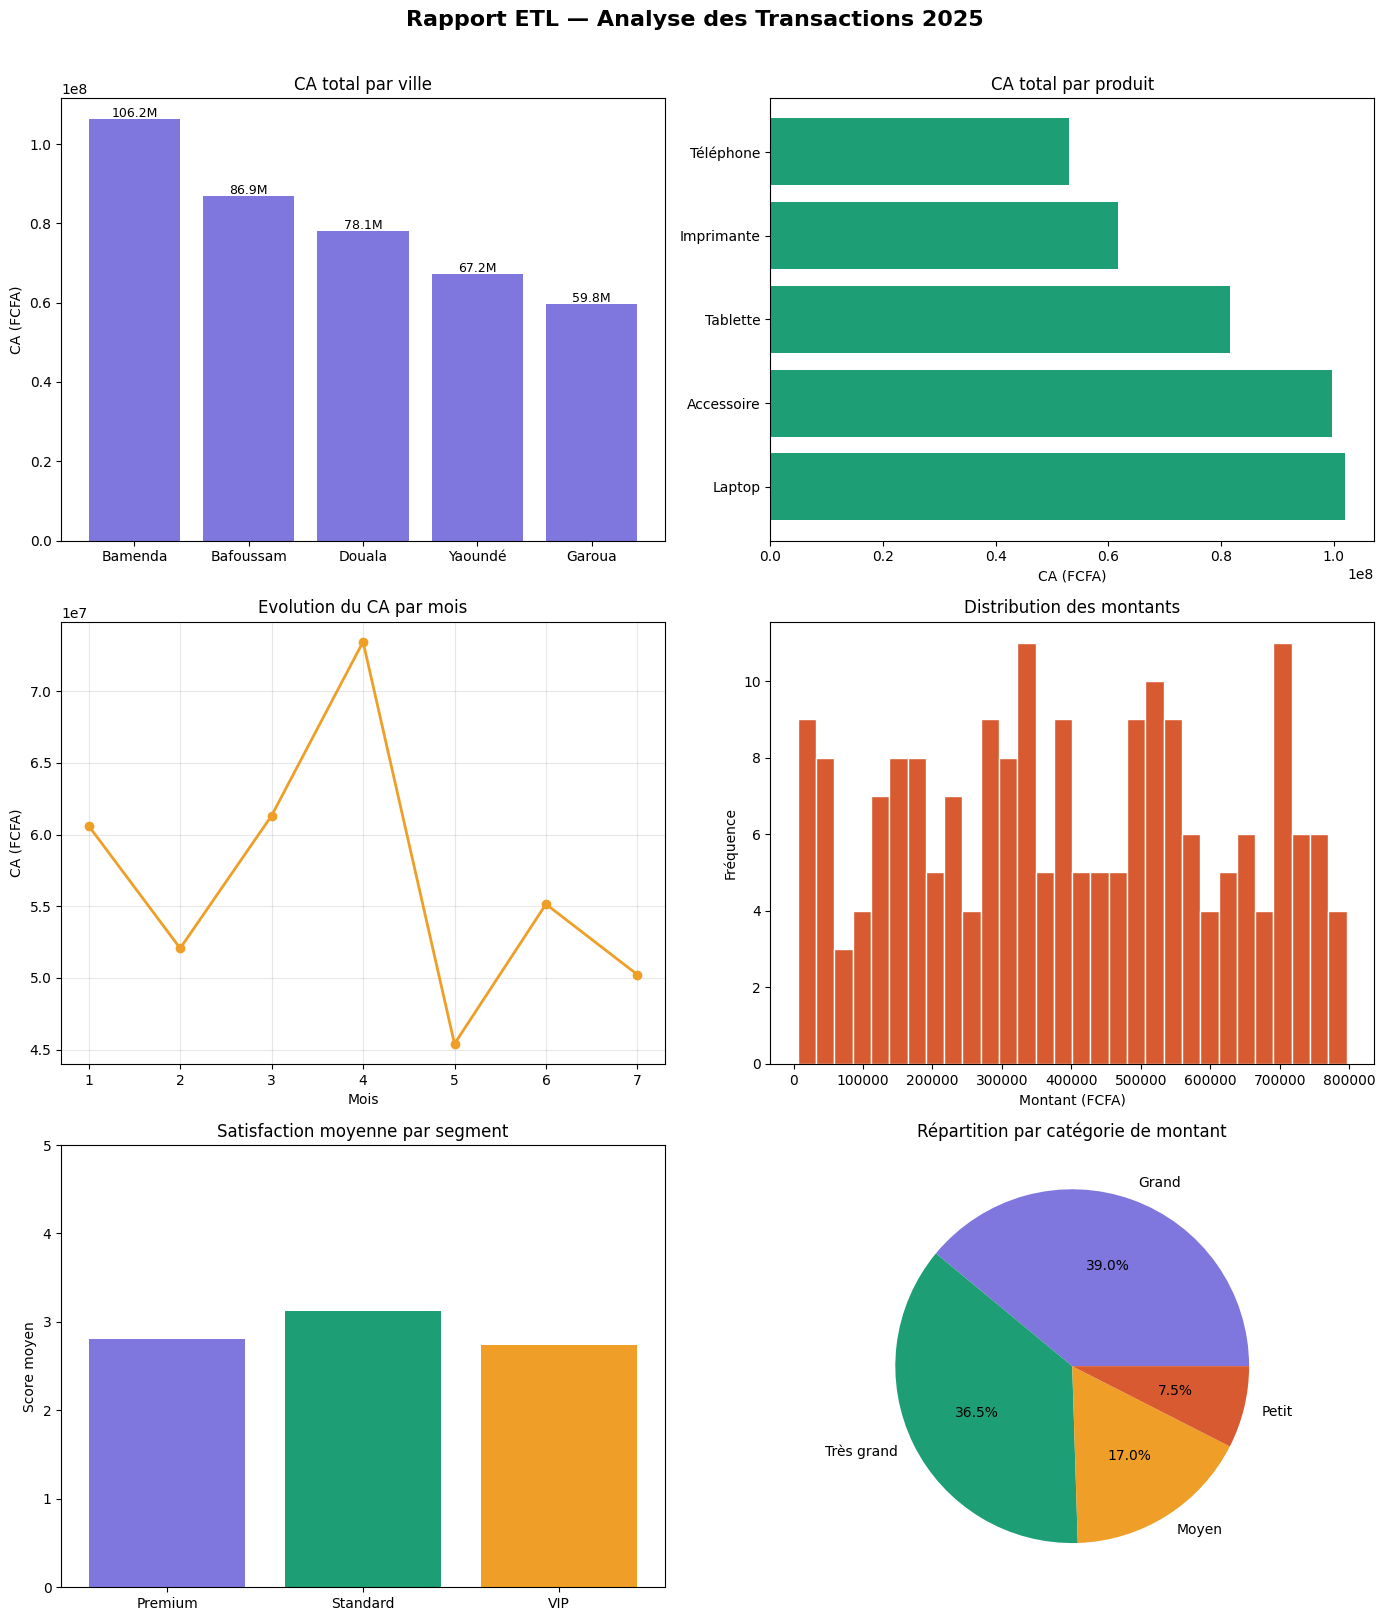


[OK] Dashboard sauvegardé !


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Rapport ETL — Analyse des Transactions 2025", 
             fontsize=16, fontweight="bold", y=1.01)

# 1. CA total par ville
ca_ville = df_enrichi.groupby("ville")["ca_total"].sum().sort_values(ascending=False)
axes[0,0].bar(ca_ville.index, ca_ville.values, color="#7F77DD")
axes[0,0].set_title("CA total par ville")
axes[0,0].set_ylabel("CA (FCFA)")
for i, v in enumerate(ca_ville.values):
    axes[0,0].text(i, v + 500000, f"{v/1e6:.1f}M", ha="center", fontsize=9)

# 2. CA par produit
ca_produit = df_enrichi.groupby("produit")["ca_total"].sum().sort_values(ascending=False)
axes[0,1].barh(ca_produit.index, ca_produit.values, color="#1D9E75")
axes[0,1].set_title("CA total par produit")
axes[0,1].set_xlabel("CA (FCFA)")

# 3. Evolution du CA par mois
ca_mois = df_enrichi.groupby("mois")["ca_total"].sum()
axes[1,0].plot(ca_mois.index, ca_mois.values, marker="o", 
               color="#EF9F27", linewidth=2)
axes[1,0].set_title("Evolution du CA par mois")
axes[1,0].set_xlabel("Mois")
axes[1,0].set_ylabel("CA (FCFA)")
axes[1,0].grid(True, alpha=0.3)

# 4. Distribution des montants
axes[1,1].hist(df_enrichi["montant"], bins=30, color="#D85A30", edgecolor="white")
axes[1,1].set_title("Distribution des montants")
axes[1,1].set_xlabel("Montant (FCFA)")
axes[1,1].set_ylabel("Fréquence")

# 5. Satisfaction par segment
sat_segment = df_enrichi.groupby("segment")["satisfaction"].mean()
colors = ["#7F77DD", "#1D9E75", "#EF9F27"]
axes[2,0].bar(sat_segment.index, sat_segment.values, color=colors)
axes[2,0].set_title("Satisfaction moyenne par segment")
axes[2,0].set_ylabel("Score moyen")
axes[2,0].set_ylim(0, 5)

# 6. Répartition par catégorie de montant
cat_montant = df_enrichi["categorie_montant"].value_counts()
axes[2,1].pie(cat_montant.values, labels=cat_montant.index, 
              autopct="%1.1f%%", colors=["#7F77DD", "#1D9E75", "#EF9F27", "#D85A30"])
axes[2,1].set_title("Répartition par catégorie de montant")

plt.tight_layout()
plt.savefig("jour06/output/dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[OK] Dashboard sauvegardé !")

<p><b style="color: red">plt.savefig()</b> sauvegarde le graphique en image — très utile pour l'intégrer dans un rapport PDF ou une présentation PowerPoint. Le dpi=150 garantit une bonne qualité d'image !</p>

 <h3 style="color:blue"><b>Le résumé final du pipeline !</b></h3>

<h4><b> Résumé et validation du pipeline :</b></h4>

In [10]:
def valider_pipeline(df, resume):
    print("=" * 50)
    print("   RAPPORT FINAL DU PIPELINE ETL")
    print("=" * 50)
    
    print(f"\n[EXTRACT]")
    print(f"  Transactions brutes     : {len(df_ventes_raw)}")
    print(f"  Clients chargés         : {len(df_clients_raw)}")
    print(f"  Taux de change          : {taux['date']}")
    
    print(f"\n[TRANSFORM]")
    print(f"  Transactions nettoyées  : {len(df)}")
    print(f"  Colonnes générées       : {df.shape[1]}")
    print(f"  Valeurs manquantes      : {df.isnull().sum().sum()}")
    
    print(f"\n[LOAD]")
    print(f"  Fichiers générés        : 3 (CSV, Excel, JSON)")
    print(f"  Feuilles Excel          : 4")
    print(f"  Dashboard               : dashboard.png")
    
    print(f"\n[STATISTIQUES]")
    print(f"  CA total                : {resume['statistiques']['ca_total_xaf']:,} FCFA")
    print(f"  CA total                : {resume['statistiques']['ca_total_eur']:,.2f} EUR")
    print(f"  Montant moyen           : {resume['statistiques']['montant_moyen']:,.0f} FCFA")
    print(f"  Satisfaction moyenne    : {resume['statistiques']['satisfaction_moyenne']}/5")
    print(f"  Meilleure ville         : {resume['top_ville']}")
    print(f"  Meilleur produit        : {resume['top_produit']}")
    
    print(f"\n[FICHIERS GÉNÉRÉS]")
    for fichier in os.listdir("jour06/output"):
        taille = os.path.getsize(f"jour06/output/{fichier}")
        print(f"  {fichier} — {taille:,} bytes")
    
    print("\n" + "=" * 50)
    print("   PIPELINE ETL COMPLÉTÉ AVEC SUCCÈS !")
    print("=" * 50)

valider_pipeline(df_enrichi, resume)

   RAPPORT FINAL DU PIPELINE ETL

[EXTRACT]
  Transactions brutes     : 200
  Clients chargés         : 50
  Taux de change          : 2026-04-03

[TRANSFORM]
  Transactions nettoyées  : 200
  Colonnes générées       : 23
  Valeurs manquantes      : 0

[LOAD]
  Fichiers générés        : 3 (CSV, Excel, JSON)
  Feuilles Excel          : 4
  Dashboard               : dashboard.png

[STATISTIQUES]
  CA total                : 398,208,901 FCFA
  CA total                : 605,277.60 EUR
  Montant moyen           : 394,155 FCFA
  Satisfaction moyenne    : 2.9/5
  Meilleure ville         : Bamenda
  Meilleur produit        : Laptop

[FICHIERS GÉNÉRÉS]
  dashboard.png — 195,737 bytes
  rapport_final.xlsx — 31,473 bytes
  resume.json — 428 bytes
  transactions_final.csv — 29,656 bytes

   PIPELINE ETL COMPLÉTÉ AVEC SUCCÈS !


<p><b style="color:red">✅ Bilan du Jour 6 — Mini-projet ETL </b><br>
Tu viens de construire ton premier pipeline de données professionnel de bout en bout !<br>
Ce que tu as réalisé aujourd'hui :<br>
✅ Extract — données générées, clients en JSON, taux de change via API<br>
✅ Transform — nettoyage, enrichissement, features temporelles, scoring<br>
✅ Load — CSV, Excel 4 feuilles, JSON, dashboard PNG<br>
✅ Logging professionnel sur tout le pipeline<br>
✅ Validation finale avec rapport complet</p>

<p> <b>💡 Ce pipeline ETL est exactement ce qu'on trouve en entreprise — la seule différence c'est que les données viendraient de vraies bases de données (PostgreSQL, MySQL) ou de vraies APIs métier. La structure reste identique !</b></p>

<p> <b>🎯 Récapitulatif de la Phase 1 (Jours 1-6)</b>
<b></b>Tu as maintenant maîtrisé :<br>
<ul>
<li>Python avancé</li>
<li>NumPy — calcul vectorisé et algèbre linéaire</li>
<li>Pandas — manipulation de données</li>
<li>Pandas avancé — merge, pivot, method chaining</li>
<li>Fichiers CSV, Excel, JSON et APIs</li>
<li>Pipeline ETL professionnel avec logging</li></p>